In [1]:
# !pip install torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
LATENT_DIM = 256
IMG_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 50
LR_G = 0.0002
LR_D = 0.0001
BETA1 = 0.5

# В тензор [0, 1] и нормализация в [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"train dataset len: {len(train_dataset)}")
print(f"test dataset len: {len(test_dataset)}")
print(f"n batches: {len(train_loader)}")

train dataset len: 60000
test dataset len: 10000
n batches: 469


In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.latent_dim = latent_dim

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 7 * 7 * 256),
            nn.BatchNorm1d(7 * 7 * 256),
            nn.ReLU(inplace=True)
        )

        self.deconv_layers = nn.Sequential(
            # 7x7x256 -> 14x14x128
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 14x14x128 -> 28x28x64
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 28x28x64 -> 28x28x1 (выходное изображение)
            nn.ConvTranspose2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)

        # Reshape: [batch, 256*7*7] -> [batch, 256, 7, 7]
        x = x.view(-1, 256, 7, 7)

        img = self.deconv_layers(x)
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.conv_layers = nn.Sequential(
            # 28x28x1 -> 14x14x64
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 14x14x64 -> 7x7x128
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 7x7x128 -> 4x4x256
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        # img: изображение размером [batch_size, 1, 28, 28]
        features = self.conv_layers(img)
        validity = self.classifier(features)
        # validity.shape Выход: torch.Size([8, 1]) [batch_size, 1]
        # validity[:3].cpu().numpy().flatten()
        # Примеры выходных значений: [0.6641002  0.49555105 0.50131327]
        return validity

Диапазон выходных значений перед денорм: [-1.000, 1.000]



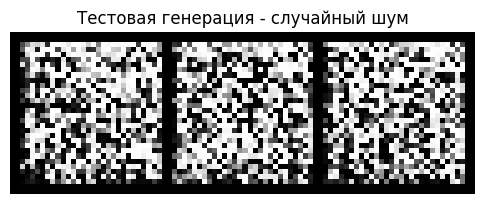

In [4]:
def test_generator():
    generator = Generator(latent_dim=LATENT_DIM).to(device)

    test_noise = torch.randn(3, LATENT_DIM).to(device)

    with torch.no_grad():
        generated = generator(test_noise)

    print(f"Диапазон выходных значений перед денорм: [{generated.min():.3f}, {generated.max():.3f}]\n")

    generated = generated * 0.5 + 0.5
    grid = make_grid(generated.cpu(), nrow=3, padding=2)

    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Тестовая генерация - случайный шум")
    plt.axis('off')
    plt.show()

    return generator

generator = test_generator()

In [5]:
def weights_init(m):
    """Инициализация весов по рекомендациям DCGAN"""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

# ДВА оптимизатора
# betas: coefficients used for computing running averages of gradient and its square
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(BETA1, 0.999))

# loss f
criterion = nn.BCELoss()

# Метки для реальных и фейковых изображений
real_label = 1.0
fake_label = 0.0

print("\nINIT SUCCESSFUL\n")
print(f"Оптимизатор генератора: Adam(lr={LR_G}, betas=({BETA1}, 0.999))")
print(f"Оптимизатор дискриминатора: Adam(lr={LR_D}, betas=({BETA1}, 0.999))")


INIT SUCCESSFUL

Оптимизатор генератора: Adam(lr=0.0002, betas=(0.5, 0.999))
Оптимизатор дискриминатора: Adam(lr=0.0001, betas=(0.5, 0.999))


In [6]:
# generator
# discriminator

Epoch 1/50: 100%|██████████| 469/469 [00:29<00:00, 16.01it/s, D_loss=0.8372, G_loss=1.2935, D(x)=0.7125, D(G(z))=0.2834]



Эпоха 1 завершена:
  Loss D: 0.8123, Loss G: 1.3164
  D(real): 0.7273, D(fake): 0.2675


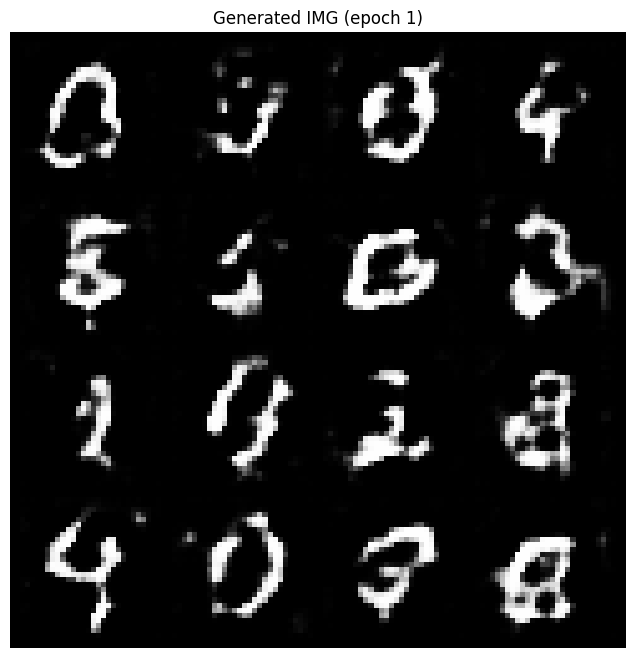

Epoch 10/50: 100%|██████████| 469/469 [00:22<00:00, 20.76it/s, D_loss=0.8676, G_loss=1.4174, D(x)=0.7259, D(G(z))=0.2596]


Эпоха 10 завершена:
  Loss D: 0.8834, Loss G: 1.2903
  D(real): 0.6806, D(fake): 0.2943


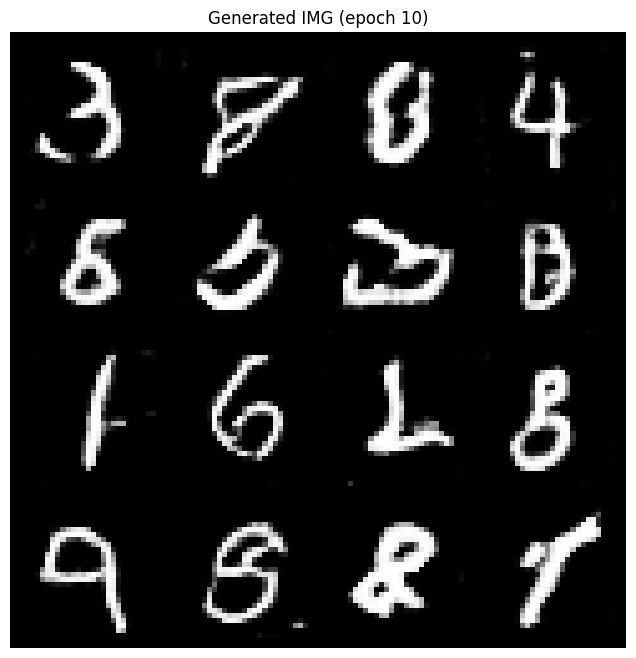

Epoch 20/50: 100%|██████████| 469/469 [00:22<00:00, 20.88it/s, D_loss=1.1202, G_loss=1.7548, D(x)=0.7549, D(G(z))=0.1866]



Эпоха 20 завершена:
  Loss D: 1.0905, Loss G: 1.5866
  D(real): 0.8126, D(fake): 0.2285


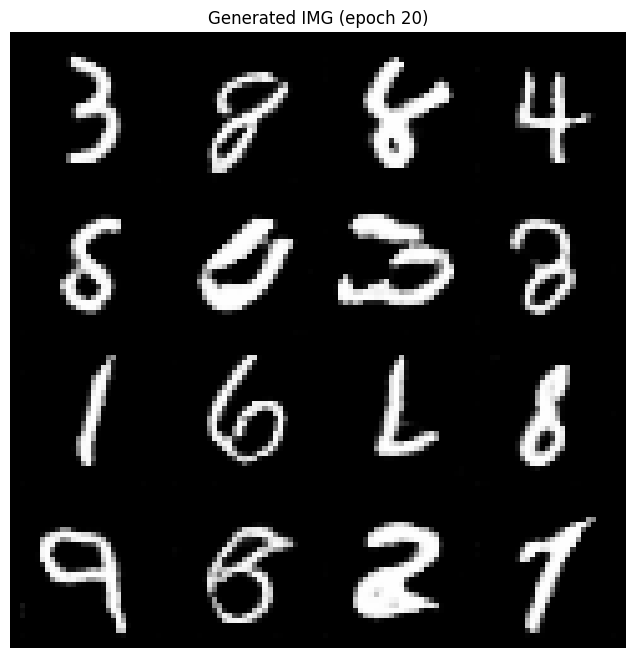

Epoch 30/50: 100%|██████████| 469/469 [00:22<00:00, 20.71it/s, D_loss=0.9173, G_loss=1.9899, D(x)=0.8396, D(G(z))=0.1447]


Эпоха 30 завершена:
  Loss D: 0.9993, Loss G: 2.0398
  D(real): 0.6627, D(fake): 0.1450


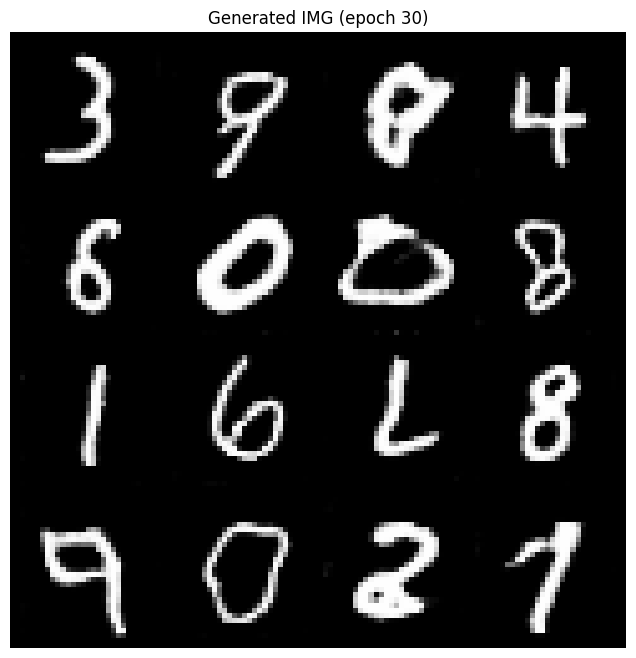

Epoch 40/50: 100%|██████████| 469/469 [00:22<00:00, 21.09it/s, D_loss=0.8875, G_loss=1.8710, D(x)=0.8121, D(G(z))=0.1684]



Эпоха 40 завершена:
  Loss D: 1.0421, Loss G: 1.2961
  D(real): 0.6548, D(fake): 0.2946


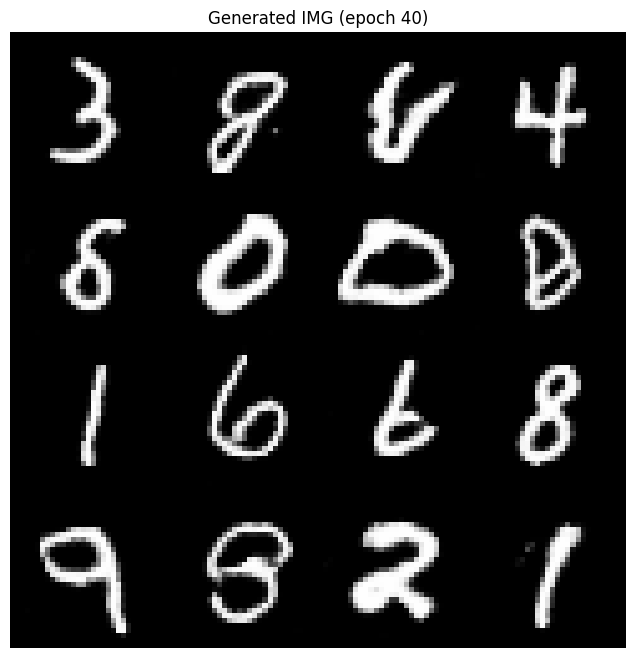

Epoch 50/50: 100%|██████████| 469/469 [00:22<00:00, 20.74it/s, D_loss=0.9336, G_loss=1.5501, D(x)=0.7409, D(G(z))=0.2290]


Эпоха 50 завершена:
  Loss D: 1.1426, Loss G: 1.2149
  D(real): 0.5456, D(fake): 0.3172


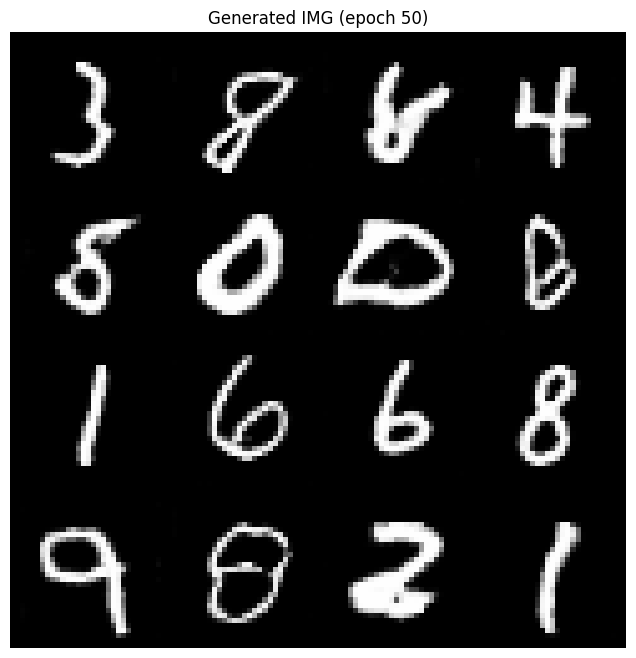


Successful!


In [7]:
G_losses = []
D_losses = []
D_real_losses = []
D_fake_losses = []

fixed_noise = torch.randn(16, LATENT_DIM, device=device)

for epoch in range(EPOCHS):
    generator.train()
    discriminator.train()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for i, (real_imgs, _) in enumerate(pbar):
        batch_size = real_imgs.size(0)

        real_imgs = real_imgs.to(device)

        # Создаем метки
        # Label Smoothing для ослабления дискриминатора
        real_labels = torch.full((batch_size, 1), 0.9, device=device)
        fake_labels = torch.full((batch_size, 1), 0.1, device=device)
        # OR real only
        # real_labels = torch.full((batch_size, 1), 0.9, device=device)
        # fake_labels = torch.full((batch_size, 1), 0.0, device=device)
        # real_labels = torch.full((batch_size, 1), real_label, device=device)
        # fake_labels = torch.full((batch_size, 1), fake_label, device=device)

        # D learn
        # реже шаг
        # if i % 3 == 0:
        optimizer_D.zero_grad()

        output_real = discriminator(real_imgs)
        loss_D_real = criterion(output_real, real_labels) # = -log(D(real))

        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = generator(noise)

        output_fake = discriminator(fake_imgs.detach())
        loss_D_fake = criterion(output_fake, fake_labels) # = -log(1 - D(fake))

        loss_D = loss_D_real + loss_D_fake # минимизируем
        loss_D.backward()
        optimizer_D.step()

        # G learn
        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = generator(noise)

        output_fake = discriminator(fake_imgs)
        loss_G = criterion(output_fake, real_labels)  # = -log(D(fake))

        loss_G.backward()
        optimizer_G.step()

        # all loss
        D_losses.append(loss_D.item())
        G_losses.append(loss_G.item())
        D_real_losses.append(loss_D_real.item())
        D_fake_losses.append(loss_D_fake.item())

        if i % 50 == 0:
            pbar.set_postfix({
                'D_loss': f'{loss_D.item():.4f}',
                'G_loss': f'{loss_G.item():.4f}',
                'D(x)': f'{output_real.mean().item():.4f}',
                'D(G(z))': f'{output_fake.mean().item():.4f}'
            })

    # progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"\nЭпоха {epoch+1} завершена:")
        print(f"  Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")
        print(f"  D(real): {output_real.mean().item():.4f}, D(fake): {output_fake.mean().item():.4f}")

        generator.eval()
        with torch.no_grad():
            fixed_fake = generator(fixed_noise)
            fixed_fake = fixed_fake * 0.5 + 0.5

            grid = make_grid(fixed_fake.cpu(), nrow=4, padding=2)

            plt.figure(figsize=(8, 8))
            plt.imshow(grid.permute(1, 2, 0))
            plt.title(f'Generated IMG (epoch {epoch+1})')
            plt.axis('off')
            plt.show()

        torch.save(generator.state_dict(), f'generator_epoch_{epoch+1}.pth')
        torch.save(discriminator.state_dict(), f'discriminator_epoch_{epoch+1}.pth')

print("\nSuccessful!")

In [8]:
# D(real) = 0.9042 - Дискриминатор слишком уверен в реальных (>0.9 - слишком хорошо!)
# D(fake) = 0.1909 - Дискриминатор хорошо определяет фейки (<0.2 - слишком хорошо!)
# loss_G = 2.2187 - ОЧЕНЬ высокий! (должен быть ~0.7)

# Идеальные целевые значения:
# D(real) ≈ 0.6-0.7 (не 0.75!)
# D(fake) ≈ 0.3-0.4 (не 0.2!)
# loss_G < 1.5 (не 2.0!)

# (уменьшили лр д)
# Эпоха 50 завершена:
#   Потеря D: 0.8129, Потеря G: 2.0306
#   D(real): 0.7544, D(fake): 0.2057

# (Обучение D реже - каждый 3й шаг)
# Эпоха 50 завершена:
#   Потеря D: 1.2916, Потеря G: 0.7138
#   D(real): 0.4714, D(fake): 0.5122

# Эпоха 50 завершена:
#   Loss D: 1.1695, Loss G: 1.5205
#   D(real): 0.6442, D(fake): 0.2262

# 3 шага
# Эпоха 50 завершена:
#   Loss D: 1.0063, Loss G: 1.0883
#   D(real): 0.7555, D(fake): 0.3687

# увеличил latent_dim 100 / 256
# Эпоха 50 завершена:
#   Loss D: 1.1426, Loss G: 1.2149
#   D(real): 0.5456, D(fake): 0.3172

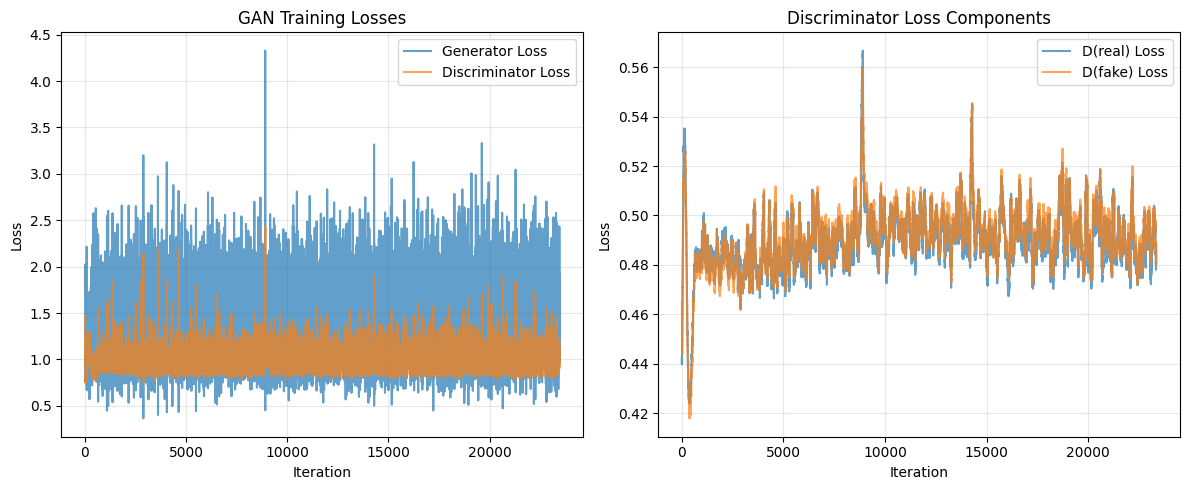

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(G_losses, label='Generator Loss', alpha=0.7)
plt.plot(D_losses, label='Discriminator Loss', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
window_size = 100
if len(D_real_losses) > window_size:

    D_real_smooth = np.convolve(D_real_losses, np.ones(window_size)/window_size, mode='valid')
    D_fake_smooth = np.convolve(D_fake_losses, np.ones(window_size)/window_size, mode='valid')

    plt.plot(D_real_smooth, label='D(real) Loss', alpha=0.7)
    plt.plot(D_fake_smooth, label='D(fake) Loss', alpha=0.7)
else:
    plt.plot(D_real_losses, label='D(real) Loss', alpha=0.7)
    plt.plot(D_fake_losses, label='D(fake) Loss', alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Discriminator Loss Components')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

G_loss должен падать (генератор улучшается)

D_loss тоже иначе дискриминатор становится сильнее
        
Идеально: обе линии около 0.7

D_loss ≈ 1.386 (-log(0.5) - log(0.5) = 0.693 + 0.693)
G_loss ≈ 0.693 (-log(0.5))
D(real) ≈ 0.5 ± 0.1
D(fake) ≈ 0.5 ± 0.1

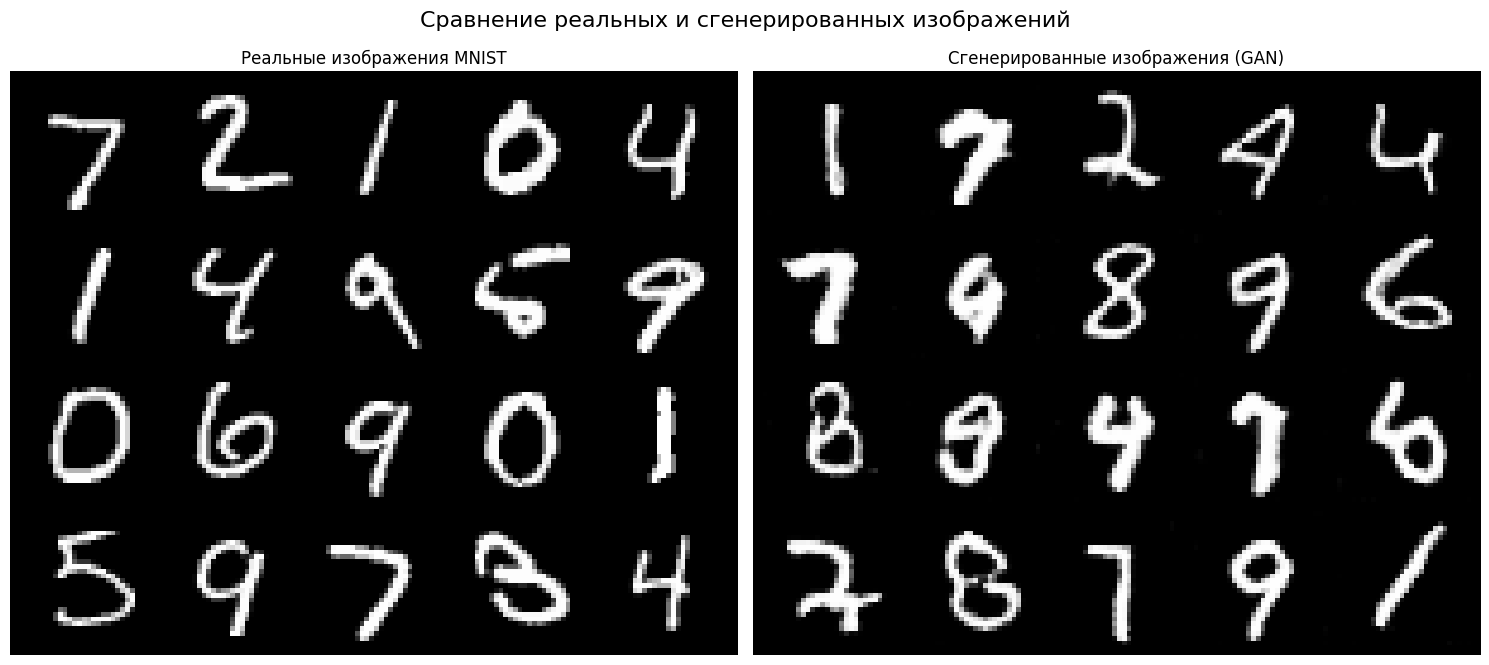

   Сравнительная статистика:
  Реальные изображения - среднее: 0.1192, std: 0.2938
  Сгенерированные - среднее: 0.1288, std: 0.3062


In [12]:
def compare_real_fake(real_loader, generator, num_samples=20):
    generator.eval()

    real_data, _ = next(iter(real_loader))
    real_data = real_data[:num_samples]

    noise = torch.randn(num_samples, LATENT_DIM, device=device)
    with torch.no_grad():
        fake_data = generator(noise)

    real_data = real_data * 0.5 + 0.5
    fake_data = fake_data * 0.5 + 0.5

    real_grid = make_grid(real_data, nrow=5, padding=2)
    fake_grid = make_grid(fake_data.cpu(), nrow=5, padding=2)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    axes[0].imshow(real_grid.permute(1, 2, 0))
    axes[0].set_title('Реальные изображения MNIST')
    axes[0].axis('off')

    axes[1].imshow(fake_grid.permute(1, 2, 0))
    axes[1].set_title('Сгенерированные изображения (GAN)')
    axes[1].axis('off')

    plt.suptitle('Сравнение реальных и сгенерированных изображений', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Статистика
    print("   Сравнительная статистика:")
    print(f"  Реальные изображения - среднее: {real_data.mean():.4f}, std: {real_data.std():.4f}")
    print(f"  Сгенерированные - среднее: {fake_data.mean():.4f}, std: {fake_data.std():.4f}")

compare_real_fake(test_loader, generator, num_samples=20)

mean = real_data.mean()  # Среднее по ВСЕМ пикселям ВСЕХ изображений

std = real_data.std()    # Стандартное отклонение по всем пикселям

Реальные: mean=0.13, std=0.30  # Типичные значения MNIST

Сгенерированные: mean=0.45, std=0.20  # ПЛОХО - слишком яркие!